In [10]:
from sklearn.preprocessing import StandardScaler

In [1]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import yfinance as yf
import pandas as pd

it_stocks = ['INFY.NS', 'WIPRO.NS', 'TCS.NS', 'HCLTECH.NS', 'TECHM.NS']

data = yf.download(it_stocks)

# Flatten multi-level columns to make them easier to work with
data.columns = [f"{col[1]}_{col[0]}" for col in data.columns]

print(data.tail())

[*********************100%***********************]  5 of 5 completed

                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2024-11-11 00:00:00+00:00           1867.300049        1860.099976   
2024-11-12 00:00:00+00:00           1872.849976        1868.800049   
2024-11-13 00:00:00+00:00           1864.750000        1868.400024   
2024-11-14 00:00:00+00:00           1858.949951        1864.550049   
2024-11-18 00:00:00+00:00                   NaN        1818.349976   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2024-11-11 00:00:00+00:00       4198.700195         1704.150024   
2024-11-12 00:00:00+00:00       4197.399902         1687.000000   
2024-11-13 00:00:00+00:00       4150.350098         1675.599976   
2024-11-14 00:00:00+00:00       4145.899902         1687.500000   
2024-11-18 00:00:00+00:00               NaN                 NaN   

                           WIPRO.NS_Adj

In [4]:
# Identify the first available data date for each stock
start_dates = {}
for ticker in it_stocks:
    adj_close_column = f"{ticker}_Adj Close"
    # Find the first non-null date for the stock
    first_valid_date = data[adj_close_column].dropna().index[0]
    start_dates[ticker] = first_valid_date

# Print out the start dates for each stock
print("\nStart dates for each stock:")
for ticker, start_date in start_dates.items():
    print(f"{ticker}: {start_date}")

# Now, filter the data to keep only the valid rows for each stock
valid_data = data.copy()

for ticker in it_stocks:
    # For each stock, filter the rows before its start date
    start_date = start_dates[ticker]
    adj_close_column = f"{ticker}_Adj Close"
    
    # Keep only rows from the stock's start date onward
    valid_data = valid_data.loc[valid_data.index >= start_date]
    
# Print the filtered data
print("\nFiltered Data:")
print(valid_data.head())


Start dates for each stock:
INFY.NS: 1996-01-01 00:00:00+00:00
WIPRO.NS: 1996-01-01 00:00:00+00:00
TCS.NS: 2002-08-12 00:00:00+00:00
HCLTECH.NS: 2002-08-12 00:00:00+00:00
TECHM.NS: 2006-08-28 00:00:00+00:00

Filtered Data:
                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2006-08-28 00:00:00+00:00             46.331295         152.274643   
2006-08-29 00:00:00+00:00             46.676998         155.113571   
2006-08-30 00:00:00+00:00             46.537113         154.718460   
2006-08-31 00:00:00+00:00             46.757389         155.165115   
2006-09-01 00:00:00+00:00             46.577305         155.517288   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2006-08-28 00:00:00+00:00        178.163254          102.649254   
2006-08-29 00:00:00+00:00        179.797638           99.880447   
2006-08-30 00:00:

In [3]:
# Print the missing counts before imputation
print("\nMissing values count (before imputation):")
missing_counts_before = valid_data.isnull().sum()
missing_counts_before = missing_counts_before[missing_counts_before > 0]  # Only show columns with missing values
for column, count in missing_counts_before.items():
    print(f"{column}: {count} missing values")

# Fill missing values using forward fill method (or you can choose other methods like bfill or interpolation)
valid_data_filled = valid_data.fillna(method='ffill')  # Forward fill

# Optionally, you can use other filling methods, for example:
# valid_data_filled = valid_data.fillna(method='bfill')  # Backward fill
# valid_data_filled = valid_data.interpolate()  # Linear interpolation

# Print the missing counts after imputation
print("\nMissing values count (after imputation):")
missing_counts_after = valid_data_filled.isnull().sum()
missing_counts_after = missing_counts_after[missing_counts_after > 0]  # Only show columns with missing values
for column, count in missing_counts_after.items():
    print(f"{column}: {count} missing values")


Missing values count (before imputation):
HCLTECH.NS_Adj Close: 1 missing values
INFY.NS_Adj Close: 2 missing values
TCS.NS_Adj Close: 2 missing values
TECHM.NS_Adj Close: 2 missing values
WIPRO.NS_Adj Close: 1 missing values
HCLTECH.NS_Close: 1 missing values
INFY.NS_Close: 2 missing values
TCS.NS_Close: 2 missing values
TECHM.NS_Close: 2 missing values
WIPRO.NS_Close: 1 missing values
HCLTECH.NS_High: 1 missing values
INFY.NS_High: 2 missing values
TCS.NS_High: 2 missing values
TECHM.NS_High: 2 missing values
WIPRO.NS_High: 1 missing values
HCLTECH.NS_Low: 1 missing values
INFY.NS_Low: 2 missing values
TCS.NS_Low: 2 missing values
TECHM.NS_Low: 2 missing values
WIPRO.NS_Low: 1 missing values
HCLTECH.NS_Open: 1 missing values
INFY.NS_Open: 2 missing values
TCS.NS_Open: 2 missing values
TECHM.NS_Open: 2 missing values
WIPRO.NS_Open: 1 missing values
HCLTECH.NS_Volume: 1 missing values
INFY.NS_Volume: 2 missing values
TCS.NS_Volume: 2 missing values
TECHM.NS_Volume: 2 missing values
WI

In [5]:
valid_data_filled.head()

,HCLTECH.NS_Adj Close,INFY.NS_Adj Close,TCS.NS_Adj Close,TECHM.NS_Adj Close,WIPRO.NS_Adj Close,HCLTECH.NS_Close,INFY.NS_Close,TCS.NS_Close,TECHM.NS_Close,WIPRO.NS_Close,...,HCLTECH.NS_Open,INFY.NS_Open,TCS.NS_Open,TECHM.NS_Open,WIPRO.NS_Open,HCLTECH.NS_Volume,INFY.NS_Volume,TCS.NS_Volume,TECHM.NS_Volume,WIPRO.NS_Volume
Date,,,,,,,,,,,,,,,,,,,,,
2006-08-28 00:00:00+00:00,46.331272,152.274643,178.163300,102.649261,97.601440,72.037498,221.593750,245.274994,138.562500,115.481255,...,71.949997,220.837494,243.750000,130.25,114.750008,1947576.0,4842896.0,2300316.0,60664652.0,2942213.0
2006-08-29 00:00:00+00:00,46.676987,155.113602,179.797623,99.880463,99.949974,72.574997,225.725006,247.524994,134.824997,118.260002,...,72.375000,222.500000,246.250000,138.75,116.325005,1741848.0,8916176.0,2679596.0,15716452.0,4115337.0
2006-08-30 00:00:00+00:00,46.537113,154.718414,178.653625,97.806160,100.092598,72.357498,225.149994,245.949997,132.024994,118.428757,...,73.000000,226.250000,247.774994,134.25,118.687508,1144272.0,5320704.0,2744772.0,8139932.0,6971084.0
2006-08-31 00:00:00+00:00,46.757385,155.165085,181.241318,99.723030,98.628342,72.699997,225.800003,249.512497,134.612503,116.696259,...,72.512497,226.000000,246.000000,131.25,118.462502,4248488.0,9828312.0,6076856.0,6683960.0,6499541.0
2006-09-01 00:00:00+00:00,46.577309,155.517288,181.459183,100.352707,98.561783,72.419998,226.312500,249.812500,135.462494,116.617508,...,72.657501,226.250000,249.000000,134.75,116.775002,508632.0,4831256.0,1728728.0,4704780.0,3401102.0


In [8]:
valid_data_filled.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4495 entries, 2006-08-28 00:00:00+00:00 to 2024-11-18 00:00:00+00:00
Data columns (total 30 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   HCLTECH.NS_Adj Close  4495 non-null   float64
 1   INFY.NS_Adj Close     4495 non-null   float64
 2   TCS.NS_Adj Close      4495 non-null   float64
 3   TECHM.NS_Adj Close    4495 non-null   float64
 4   WIPRO.NS_Adj Close    4495 non-null   float64
 5   HCLTECH.NS_Close      4495 non-null   float64
 6   INFY.NS_Close         4495 non-null   float64
 7   TCS.NS_Close          4495 non-null   float64
 8   TECHM.NS_Close        4495 non-null   float64
 9   WIPRO.NS_Close        4495 non-null   float64
 10  HCLTECH.NS_High       4495 non-null   float64
 11  INFY.NS_High          4495 non-null   float64
 12  TCS.NS_High           4495 non-null   float64
 13  TECHM.NS_High         4495 non-null   float64
 14  WIPRO.NS_High         44

                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2006-08-28 00:00:00+00:00             46.331272         152.274643   
2006-08-29 00:00:00+00:00             46.676987         155.113602   
2006-08-30 00:00:00+00:00             46.537113         154.718414   
2006-08-31 00:00:00+00:00             46.757385         155.165085   
2006-09-01 00:00:00+00:00             46.577309         155.517288   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2006-08-28 00:00:00+00:00        178.163300          102.649261   
2006-08-29 00:00:00+00:00        179.797623           99.880463   
2006-08-30 00:00:00+00:00        178.653625           97.806160   
2006-08-31 00:00:00+00:00        181.241318           99.723030   
2006-09-01 00:00:00+00:00        181.459183          100.352707   

                           WIPRO.NS_Adj

<Axes: xlabel='Date'>

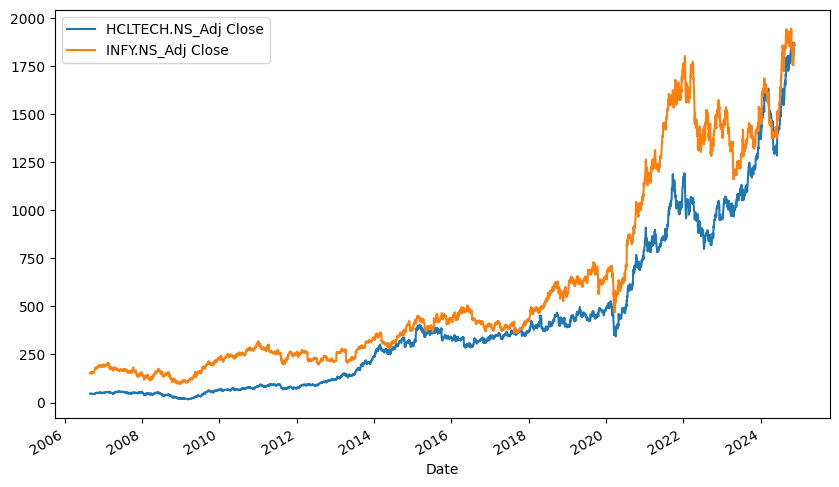

In [9]:
print(valid_data_filled.head())  # Check the first few rows
valid_data_filled[['HCLTECH.NS_Adj Close', 'INFY.NS_Adj Close']].plot(figsize=(10, 6))  # Plot some stocks' adjusted close prices

In [11]:
valid_data_filled.to_csv('IT_Stocks_Historical_Data_Raw.csv', index=True)
print("Raw data saved to 'IT_Stocks_Historical_Data_Raw.csv'")

Raw data saved to 'IT_Stocks_Historical_Data_Raw.csv'


In [12]:
# Identify stock columns for scaling (those containing adjusted closing prices)
stock_columns = [col for col in valid_data_filled.columns if 'Adj Close' in col]

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply scaling (standardization) only to the stock price columns
valid_data_filled[stock_columns] = scaler.fit_transform(valid_data_filled[stock_columns])

# Check the data after scaling
print(valid_data_filled.head())

                           HCLTECH.NS_Adj Close  INFY.NS_Adj Close  \
Date                                                                 
2006-08-28 00:00:00+00:00             -0.895973          -0.890982   
2006-08-29 00:00:00+00:00             -0.895150          -0.885256   
2006-08-30 00:00:00+00:00             -0.895483          -0.886053   
2006-08-31 00:00:00+00:00             -0.894958          -0.885152   
2006-09-01 00:00:00+00:00             -0.895387          -0.884442   

                           TCS.NS_Adj Close  TECHM.NS_Adj Close  \
Date                                                              
2006-08-28 00:00:00+00:00         -1.021008           -1.006697   
2006-08-29 00:00:00+00:00         -1.019644           -1.013688   
2006-08-30 00:00:00+00:00         -1.020599           -1.018926   
2006-08-31 00:00:00+00:00         -1.018438           -1.014086   
2006-09-01 00:00:00+00:00         -1.018256           -1.012496   

                           WIPRO.NS_Adj

In [13]:
# After scaling the data for GRU/LSTM
valid_data_filled[stock_columns] = scaler.fit_transform(valid_data_filled[stock_columns])

valid_data_filled.to_csv('IT_Stocks_Historical_Data_Scaled.csv', index=True)
print("Scaled data saved to 'IT_Stocks_Historical_Data_Scaled.csv'")

Scaled data saved to 'IT_Stocks_Historical_Data_Scaled.csv'


In [1]:
import os

current_directory = os.getcwd()
print("Current directory:", current_directory)

Current directory: C:\Users\Aniket Shinde
